**Entrenamiento** redes neuronales con Keras

En esta primera parte, vamos a utilizar una red neuronal para clasificar imágenes de prendas de ropa. Para ello, utilizaremos Keras con TensorFlow.

El dataset a utilizar es Fashion MNIST, un problema sencillo con imágenes pequeñas de ropa, pero más interesante que el dataset de MNIST. Puedes consultar más información sobre el dataset en [este enlace](https://github.com/zalandoresearch/fashion-mnist).

El código utilizado para contestar tiene que quedar claramente reflejado en el Notebook. Puedes crear nuevas cells si así lo deseas para estructurar tu código y sus salidas. A la hora de entregar el notebook, **asegúrate de que los resultados de ejecutar tu código han quedado guardados** (por ejemplo, a la hora de entrenar una red neuronal tiene que verse claramente un log de los resultados de cada epoch).

In [2]:
import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf

import matplotlib.pyplot as plt

Primero, vamos a obtener los datos. Por suerte para nosotros, estos pueden ser descargados directamente desde Keras, por lo que no tendremos que preocuparnos de tratar con ficheros.

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Acto seguido, normalizamos esos datos de manera similar a como hemos visto con MNIST, obteniendo valores entre 0 y 1. Este paso es muy importante para el correcto funcionamiento de nuestra red.

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

## 1. Información sobre el dataset

Una vez tenemos los datos cargados en memoria, vamos a obtener información sobre los mismos.

**Pregunta 1.1 ** ¿Cuántas imágenes hay de *training* y de *test*? ¿Qué tamaño tienen las imágenes?

In [7]:
### Tu código aquí ###
print(f'X_train: {x_train.shape}')
print(f'Y_train: {y_train.shape}')
print(f'X_test: {x_test.shape}')
print(f'Y_test: {y_test.shape}')

X_train: (60000, 28, 28)
Y_train: (60000,)
X_test: (10000, 28, 28)
Y_test: (10000,)


*Tu respuesta aquí*

**Pregunta 1.2 ** Realizar una exploración de las variables que contienen los datos. Describir en qué consiste un example del dataset (qué información se guarda en cada imagen) y describir qué contiene la información en y.

In [8]:
### Tu código aquí ###
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [12]:
y_train[0]

np.uint8(9)

Los datos de train contienen una matriz de 28x28 con la información numérica de la imagen normalizada.

Los datos de test contienen un valor que referencia al tipo de ropa al que pertenece.

Vamos a **visualizar** una imagen de ejemplo. Prueba tu mismo a cambiar la imagen en uso para explorar el dataset visualmente ejecutando el siguiente código:

In [14]:
def visualize_example(x):
    plt.figure()
    plt.imshow(x)
    plt.colorbar()
    plt.grid(False)
    plt.show()

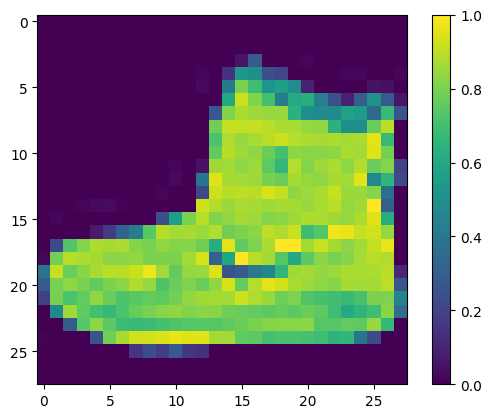

In [16]:
visualize_example(x_train[0])

## 2. Entrenamiento de una red neuronal simple

**Pregunta 2 **. Utilizando Keras, y preparando los datos de X e y como fuera necesario, define y entrena una red neuronal que sea capaz de clasificar imágenes de Fashion MNIST con las siguientes características:

* Dos hidden layers de tamaños 128 y 64, utilizando unidades **sigmoid**
* Optimizador **sgd**.
* Durante el entrenamiento, la red tiene que mostrar resultados de **loss** y **accuracy** por cada epoch.
* La red debe entrenar durante **20 epochs** y batch size de **64**.
* La última capa debe de ser una capa **softmax**.

Tu red tendría que ser capaz de superar fácilmente 60% de accuracy.

## Prepare Data for Neural Network

### Subtask:
Flatten the input images (x_train and x_test) from 28x28 to 784-dimensional vectors, as Keras Dense layers expect 2D input. No changes are needed for y_train and y_test.


**Reasoning**:
The subtask requires flattening the input images from 28x28 to 784-dimensional vectors. This can be achieved by reshaping `x_train` and `x_test`.



In [17]:
x_train_flat = x_train.reshape(x_train.shape[0], 784)
x_test_flat = x_test.reshape(x_test.shape[0], 784)

print(f'Shape of x_train_flat: {x_train_flat.shape}')
print(f'Shape of x_test_flat: {x_test_flat.shape}')

Shape of x_train_flat: (60000, 784)
Shape of x_test_flat: (10000, 784)


## Define the Neural Network Model

### Subtask:
Create a Keras Sequential model. Add a Flatten layer as the input, two Dense hidden layers with 128 and 64 units respectively, both using 'sigmoid' activation, and a final Dense output layer with 10 units and 'softmax' activation.


**Reasoning**:
The subtask requires defining a Keras Sequential model with specific layers and activation functions. I will create a code block to instantiate the Sequential model, add a Flatten layer with the correct input shape, two Dense hidden layers with sigmoid activation, and a final Dense output layer with softmax activation and 10 units.



In [22]:
model = Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    Dense(128, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(10, activation='softmax')
])
print("Model created successfully.")
model.summary()

Model created successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Subtask:
* Optimizador **sgd**.
* Durante el entrenamiento, la red tiene que mostrar resultados de **loss** y **accuracy** por cada epoch.
* La red debe entrenar durante **20 epochs** y batch size de **64**.

In [24]:
# Compilamos el modelo
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [25]:
batch_size = 64
epochs = 20
# Entrenamos el modelo
history = model.fit(x_train, y_train,
                    batch_size = batch_size,
                    epochs = epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

#


Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2696 - loss: 2.2635 - val_accuracy: 0.4366 - val_loss: 2.0306
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5067 - loss: 1.9186 - val_accuracy: 0.5812 - val_loss: 1.5946
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5978 - loss: 1.5099 - val_accuracy: 0.6371 - val_loss: 1.3089
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6455 - loss: 1.2566 - val_accuracy: 0.6636 - val_loss: 1.1350
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6763 - loss: 1.0941 - val_accuracy: 0.6877 - val_loss: 1.0152
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6965 - loss: 0.9871 - val_accuracy: 0.7126 - val_loss: 0.9260
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7196 - loss: 0.8994 - val_accuracy: 0.7171 - val_loss: 0.8575
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7277 - loss: 0.8339 - val_accuracy: 0.

## 3. Evaluación del modelo en datos de test

Una vez hemos entrenado nuestro modelo, vamos a evaluarlo en los datos de test de Fashion MNIST.

**Pregunta 3.1 ***. Utilizando el modelo recién entrenado, obtener la accuracy resultante en el dataset de test.

In [32]:
score = model.evaluate(x_test, y_test, verbose=0)
print(score[1])

0.7955999970436096


**Pregunta 3.2 **. Utilizando el método **predict** de Keras, realizar predicciones para los datos de test. Por cada predicción resultante, ¿qué significan los números que obtenemos al hacer predict? ¿Cómo podemos obtener el valor de la clase resultante? (recordar que estamos utilizando una capa softmax para clasificar).

*Tu respuesta aquí*

**Reasoning**:
The subtask requires using the trained Keras model's `predict()` method on the `x_test` data to obtain raw predictions. This code block will perform the prediction and store the results in a variable.



In [33]:
predictions = model.predict(x_test)
print(f'Shape of predictions: {predictions.shape}')
print(f'First prediction: {predictions[0]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Shape of predictions: (10000, 10)
First prediction: [1.3765243e-04 3.2833676e-04 2.0480841e-04 1.5794560e-04 4.6644974e-04
 2.0534745e-01 3.7628724e-04 2.8163755e-01 1.6448868e-02 4.9489465e-01]


Cuando realizamos `model.predict(x_test)`, el modelo retorna un array de arrays, donde cada sub-array corresponde a una imagen de entrada. Para cada imagen, el sub-array contiene 10 números (uno por cada clase posible, ya que tenemos 10 categorías de ropa en Fashion MNIST).

Estos números son las **probabilidades** que la capa `softmax` ha asignado a cada clase para esa imagen en particular. La suma de estas probabilidades para cada imagen es aproximadamente 1 (puede haber pequeñas diferencias debido a la precisión de punto flotante).

Para obtener el valor de la clase resultante, es decir, la clase predicha con mayor probabilidad, debemos encontrar el índice de la probabilidad más alta en cada sub-array de predicción. Keras no devuelve directamente la clase predicha, sino las probabilidades de cada clase. Utilizaremos `np.argmax` para obtener el índice de la clase con mayor probabilidad.

**Reasoning**:
To demonstrate how to obtain the predicted class from the softmax output, I will use `np.argmax` on the `predictions` array to get the index of the highest probability for each image.



In [34]:
import numpy as np

predicted_classes = np.argmax(predictions, axis=1)

print(f'Shape of predicted_classes: {predicted_classes.shape}')
print(f'First 10 predicted classes: {predicted_classes[:10]}')
print(f'First 10 actual classes: {y_test[:10]}')

Shape of predicted_classes: (10000,)
First 10 predicted classes: [9 2 1 1 6 1 6 6 5 7]
First 10 actual classes: [9 2 1 1 6 1 4 6 5 7]
